# 02 — Clustering Exploratorio
### Freesound Audio Tagging 2019

Aquí aplicamos los mismos algoritmos del cuadernillo base (K-Means, GMM, DBSCAN)
directamente sobre los vectores de features extraídos en el cuadernillo 01.


## 1. Carga de datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, MiniBatchKMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score, silhouette_samples
from matplotlib.ticker import FixedLocator, FixedFormatter
import matplotlib as mpl
import warnings
warnings.filterwarnings('ignore')

FEATURES_DIR = Path("features")

# Cargar features
X_curated = np.load(FEATURES_DIR / "X_curated.npy")
y_curated = np.load(FEATURES_DIR / "y_curated.npy")
X_noisy   = np.load(FEATURES_DIR / "X_noisy.npy")

with open(FEATURES_DIR / "label_encoder.pkl", "rb") as f:
    le = pickle.load(f)

N_CLASSES = len(le.classes_)
print(f"X_curated : {X_curated.shape}")
print(f"y_curated : {y_curated.shape}")
print(f"X_noisy   : {X_noisy.shape}")
print(f"Clases    : {N_CLASSES}")

X_curated : (4970, 80)
y_curated : (4970,)
X_noisy   : (19815, 80)
Clases    : 78


## 2. Preprocesamiento — Normalización

Los algoritmos de clustering son sensibles a la escala. Normalizamos las features.

In [2]:
# Combinamos curated + noisy para escalar juntos
X_all = np.vstack([X_curated, X_noisy])

scaler = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

# Separar de vuelta
n_curated = len(X_curated)
X_curated_scaled = X_all_scaled[:n_curated]
X_noisy_scaled   = X_all_scaled[n_curated:]

# Guardar el scaler para usarlo en los cuadernillos siguientes
with open(FEATURES_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print(f"X_curated_scaled: {X_curated_scaled.shape}")
print(f"Media: {X_curated_scaled.mean():.4f} | Std: {X_curated_scaled.std():.4f}")

X_curated_scaled: (4970, 80)
Media: -0.1282 | Std: 1.0256


## 3. Reducción de dimensionalidad — PCA

Primero reducimos a 2D con PCA para visualizar. Luego usaremos más componentes
para el clustering real.

In [3]:
# PCA para visualización (2 componentes)
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_curated_scaled)

print(f"Varianza explicada por 2 componentes: {pca_2d.explained_variance_ratio_.sum():.1%}")

# PCA para clustering (suficiente para capturar ~95% de varianza)
pca_full = PCA(n_components=0.95, random_state=42)
X_pca_full = pca_full.fit_transform(X_curated_scaled)
print(f"Componentes para 95% de varianza: {X_pca_full.shape[1]}")

Varianza explicada por 2 componentes: 44.3%
Componentes para 95% de varianza: 56


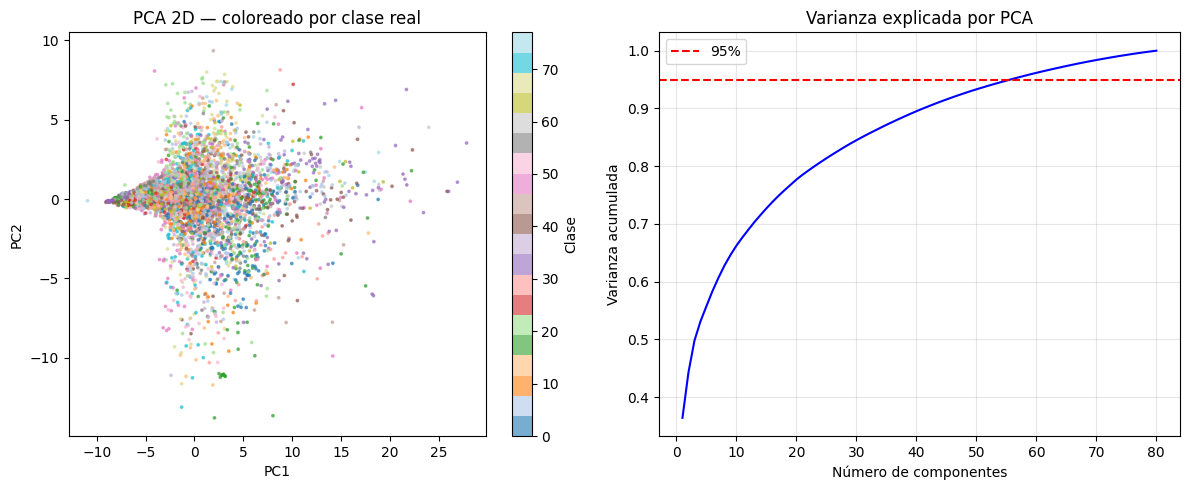

In [4]:
# Visualización PCA coloreado por clase real (curated tiene etiquetas)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
scatter = plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1],
                      c=y_curated, s=3, cmap='tab20', alpha=0.6)
plt.title("PCA 2D — coloreado por clase real")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar(scatter, label="Clase")

# Curva de varianza acumulada
plt.subplot(1, 2, 2)
pca_all = PCA(random_state=42).fit(X_curated_scaled)
var_cum = np.cumsum(pca_all.explained_variance_ratio_)
plt.plot(range(1, len(var_cum)+1), var_cum, 'b-')
plt.axhline(y=0.95, color='r', linestyle='--', label='95%')
plt.xlabel("Número de componentes")
plt.ylabel("Varianza acumulada")
plt.title("Varianza explicada por PCA")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Encontrar el k óptimo — Inercia + Silhouette

Igual que en el cuadernillo base, pero sobre datos de audio.

In [53]:
# Usamos PCA reducido para acelerar el cómputo
X_for_clustering = X_pca_full

# Rango de k a probar
k_range = range(2, min(N_CLASSES + 5, 20))  # Hasta 20 o N_CLASSES+4
#k_range = range(2, 150)  # Prueba con K=150

print(f"Probando k de 2 a {max(k_range)}...")

inertias         = []
silhouette_scores = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=5)
    km.fit(X_for_clustering)
    inertias.append(km.inertia_)
    score = silhouette_score(X_for_clustering, km.labels_, sample_size=2000)
    silhouette_scores.append(score)
    print(f"  k={k:2d} | inercia={km.inertia_:.0f} | silhouette={score:.4f}")

Probando k de 2 a 19...
  k= 2 | inercia=236708 | silhouette=0.2720
  k= 3 | inercia=210811 | silhouette=0.1703
  k= 4 | inercia=199175 | silhouette=0.1575
  k= 5 | inercia=189759 | silhouette=0.1443
  k= 6 | inercia=183264 | silhouette=0.1214
  k= 7 | inercia=178140 | silhouette=0.1280
  k= 8 | inercia=174463 | silhouette=0.0887
  k= 9 | inercia=170753 | silhouette=0.0993
  k=10 | inercia=168089 | silhouette=0.1075
  k=11 | inercia=165876 | silhouette=0.1130
  k=12 | inercia=163651 | silhouette=0.0820
  k=13 | inercia=161398 | silhouette=0.1049
  k=14 | inercia=159402 | silhouette=0.0901
  k=15 | inercia=157460 | silhouette=0.0799
  k=16 | inercia=155613 | silhouette=0.0922
  k=17 | inercia=153637 | silhouette=0.0871
  k=18 | inercia=152496 | silhouette=0.0946
  k=19 | inercia=151688 | silhouette=0.0938


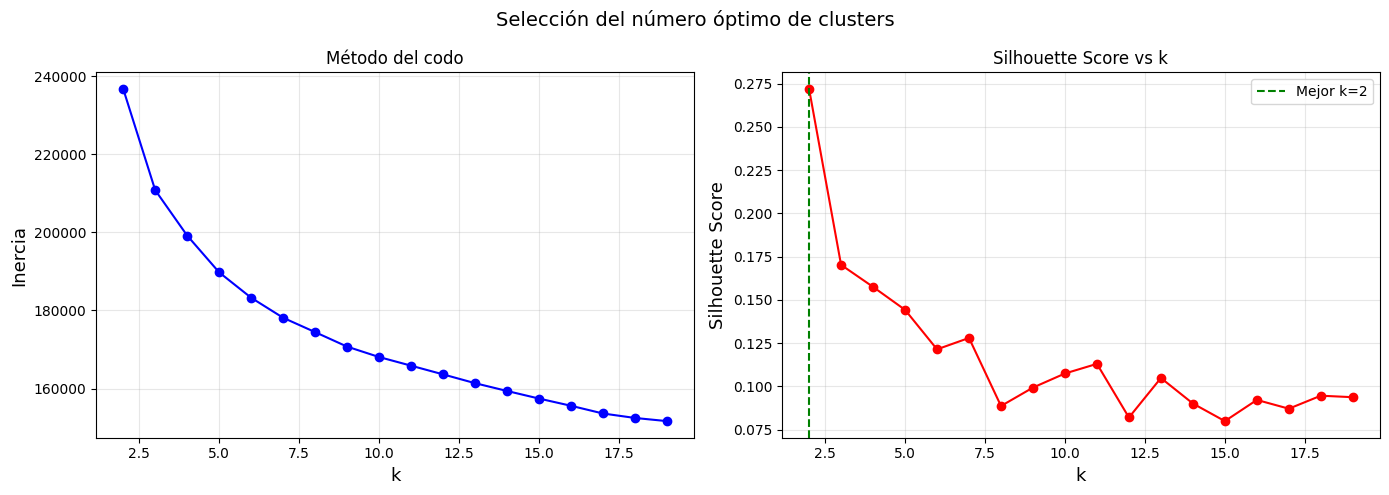


Mejor k según Silhouette: 2
Número real de clases en el dataset: 78


In [54]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Método del codo
axes[0].plot(list(k_range), inertias, 'bo-', markersize=6)
axes[0].set_xlabel("k", fontsize=13)
axes[0].set_ylabel("Inercia", fontsize=13)
axes[0].set_title("Método del codo")
axes[0].grid(True, alpha=0.3)

# Silhouette score
best_k = list(k_range)[np.argmax(silhouette_scores)]
axes[1].plot(list(k_range), silhouette_scores, 'ro-', markersize=6)
axes[1].axvline(x=best_k, color='green', linestyle='--', label=f'Mejor k={best_k}')
axes[1].set_xlabel("k", fontsize=13)
axes[1].set_ylabel("Silhouette Score", fontsize=13)
axes[1].set_title("Silhouette Score vs k")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("Selección del número óptimo de clusters", fontsize=14)
plt.tight_layout()
plt.show()

print(f"\nMejor k según Silhouette: {best_k}")
print(f"Número real de clases en el dataset: {N_CLASSES}")

## 5. K-Means con el k óptimo

In [42]:
# Podemos usar el k óptimo encontrado o el número real de clases
# Para el enfoque semisupervisado del cuadernillo 03, usamos N_CLASSES
K_OPTIMAL = N_CLASSES
#K_OPTIMAL = best_k

print(f"Entrenando K-Means con k={K_OPTIMAL}...")
kmeans = KMeans(n_clusters=K_OPTIMAL, init='k-means++', n_init=10, random_state=42)
kmeans.fit(X_for_clustering)

# Guardar el modelo
with open(FEATURES_DIR / "kmeans_model.pkl", "wb") as f:
    pickle.dump(kmeans, f)

# Guardar el PCA
with open(FEATURES_DIR / "pca_model.pkl", "wb") as f:
    pickle.dump(pca_full, f)

print(f"Silhouette score final: {silhouette_score(X_for_clustering, kmeans.labels_, sample_size=3000):.4f}")
print(f"Inercia: {kmeans.inertia_:.0f}")

Entrenando K-Means con k=78...
Silhouette score final: 0.0521
Inercia: 113493


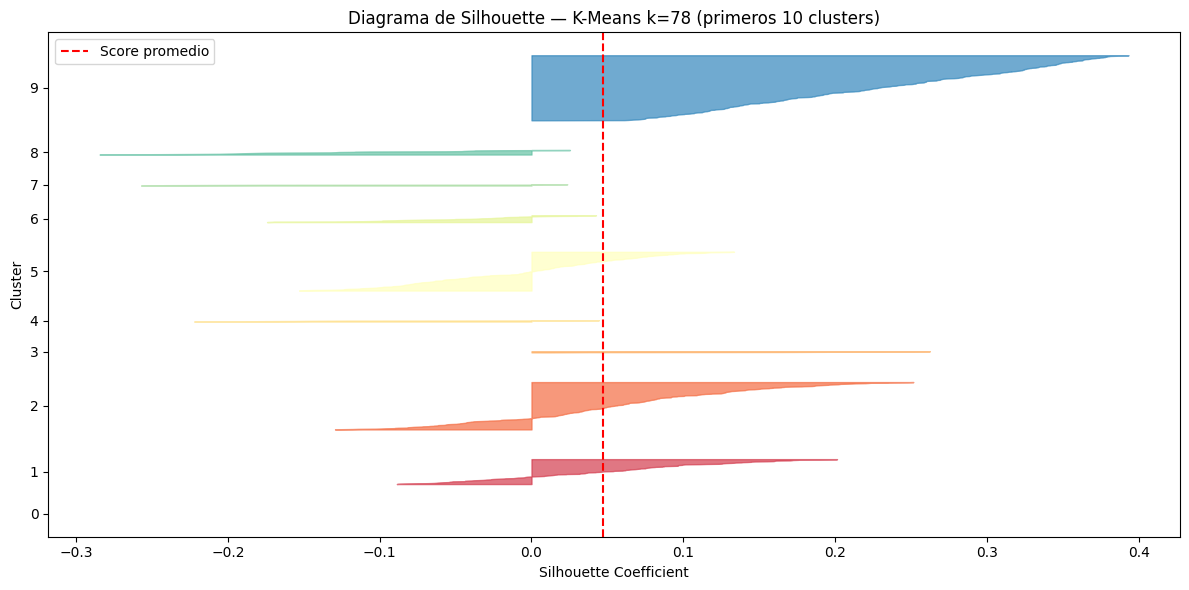

In [46]:
# Diagrama de Silhouette por cluster
y_pred = kmeans.labels_
silhouette_vals = silhouette_samples(X_for_clustering, y_pred)

# Mostrar sólo los primeros 10 clusters para legibilidad
K_SHOW = min(10, K_OPTIMAL)

plt.figure(figsize=(12, 6))
padding = len(X_for_clustering) // 30
pos = padding
ticks = []

for i in range(K_SHOW):
    coeffs = silhouette_vals[y_pred == i]
    coeffs.sort()
    color = mpl.cm.Spectral(i / K_SHOW)
    plt.fill_betweenx(np.arange(pos, pos + len(coeffs)), 0, coeffs,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ticks.append(pos + len(coeffs) // 2)
    pos += len(coeffs) + padding

plt.gca().yaxis.set_major_locator(FixedLocator(ticks))
plt.gca().yaxis.set_major_formatter(FixedFormatter(range(K_SHOW)))
plt.axvline(x=silhouette_score(X_for_clustering, y_pred, sample_size=3000),
            color='red', linestyle='--', label='Score promedio')
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")
plt.title(f"Diagrama de Silhouette — K-Means k={K_OPTIMAL} (primeros {K_SHOW} clusters)")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Visualización t-SNE

t-SNE es mejor que PCA para visualizar clusters en datos de alta dimensión.

In [48]:
# Muestra para t-SNE (no escalar a todo el dataset, tarda demasiado)
N_TSNE = 3000
idx_sample = np.random.choice(len(X_for_clustering), N_TSNE, replace=False)
X_sample   = X_for_clustering[idx_sample]
y_sample   = y_curated[idx_sample]
labels_sample = kmeans.labels_[idx_sample]

print(f"Calculando t-SNE sobre {N_TSNE} muestras...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_sample)
print("t-SNE listo.")

Calculando t-SNE sobre 3000 muestras...
t-SNE listo.


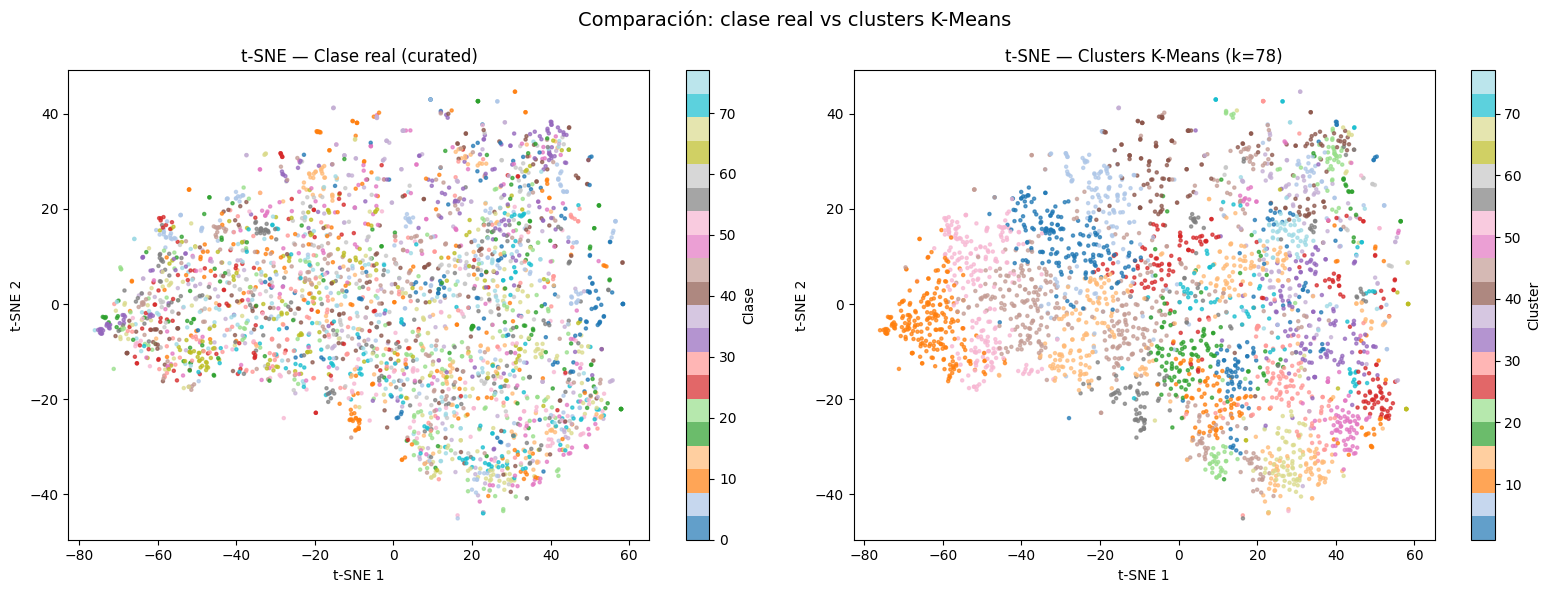

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Coloreado por clase real
sc1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=y_sample, s=5, cmap='tab20', alpha=0.7)
axes[0].set_title("t-SNE — Clase real (curated)")
axes[0].set_xlabel("t-SNE 1")
axes[0].set_ylabel("t-SNE 2")
plt.colorbar(sc1, ax=axes[0], label="Clase")

# Coloreado por cluster K-Means
sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=labels_sample, s=5, cmap='tab20', alpha=0.7)
axes[1].set_title(f"t-SNE — Clusters K-Means (k={K_OPTIMAL})")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
plt.colorbar(sc2, ax=axes[1], label="Cluster")

plt.suptitle("Comparación: clase real vs clusters K-Means", fontsize=14)
plt.tight_layout()
plt.show()

## 7. Identificar representantes por cluster

Encontramos el audio más cercano
al centroide de cada cluster. Estos serán los "representantes" para el cuadernillo 03.

In [56]:
# Distancias de cada punto a cada centroide
X_dist = kmeans.transform(X_for_clustering)  # shape: (n_samples, k)

# Para cada cluster, el índice del punto MÁS CERCANO al centroide
representative_idxs = np.argmin(X_dist, axis=0)

print(f"Representantes encontrados: {len(representative_idxs)}")
print("\nClase real de cada representante:")
for cluster_id, idx in enumerate(representative_idxs[:10]):
    clase = le.classes_[y_curated[idx]]
    print(f"  Cluster {cluster_id:2d} → índice {idx:4d} → clase: {clase}")

Representantes encontrados: 78

Clase real de cada representante:
  Cluster  0 → índice 3942 → clase: Accordion
  Cluster  1 → índice 1034 → clase: Chewing_and_mastication
  Cluster  2 → índice 3212 → clase: Bathtub_(filling_or_washing)
  Cluster  3 → índice 3085 → clase: Female_singing
  Cluster  4 → índice  811 → clase: Accordion
  Cluster  5 → índice 4900 → clase: Female_speech_and_woman_speaking
  Cluster  6 → índice 4147 → clase: Harmonica
  Cluster  7 → índice 4859 → clase: Toilet_flush
  Cluster  8 → índice 3726 → clase: Hiss
  Cluster  9 → índice 4307 → clase: Printer


In [58]:
# Guardar índices de representantes para el cuadernillo 03
np.save(FEATURES_DIR / "representative_idxs.npy", representative_idxs)
np.save(FEATURES_DIR / "X_curated_scaled.npy",    X_curated_scaled)
np.save(FEATURES_DIR / "X_noisy_scaled.npy",      X_noisy_scaled)
np.save(FEATURES_DIR / "X_pca_full.npy",          X_pca_full)

print("Guardado:")
print("  representative_idxs.npy")
print("  X_curated_scaled.npy")
print("  X_noisy_scaled.npy")
print("  X_pca_full.npy")

Guardado:
  representative_idxs.npy
  X_curated_scaled.npy
  X_noisy_scaled.npy
  X_pca_full.npy


## 8. Gaussian Mixture Model (GMM)

Alternativa probabilística a K-Means, como en el cuadernillo base.

In [13]:
print(f"Entrenando GMM con {K_OPTIMAL} componentes...")
gm = GaussianMixture(n_components=K_OPTIMAL, n_init=3, random_state=42,
                     covariance_type='diag')  # 'diag' es más rápido que 'full'
gm.fit(X_for_clustering)

gm_labels = gm.predict(X_for_clustering)
gm_score  = silhouette_score(X_for_clustering, gm_labels, sample_size=3000)

print(f"GMM Silhouette score: {gm_score:.4f}")
print(f"K-Means Silhouette score: {silhouette_score(X_for_clustering, kmeans.labels_, sample_size=3000):.4f}")

with open(FEATURES_DIR / "gmm_model.pkl", "wb") as f:
    pickle.dump(gm, f)
print("gmm_model.pkl guardado.")

Entrenando GMM con 78 componentes...
GMM Silhouette score: -0.0569
K-Means Silhouette score: 0.0512
gmm_model.pkl guardado.


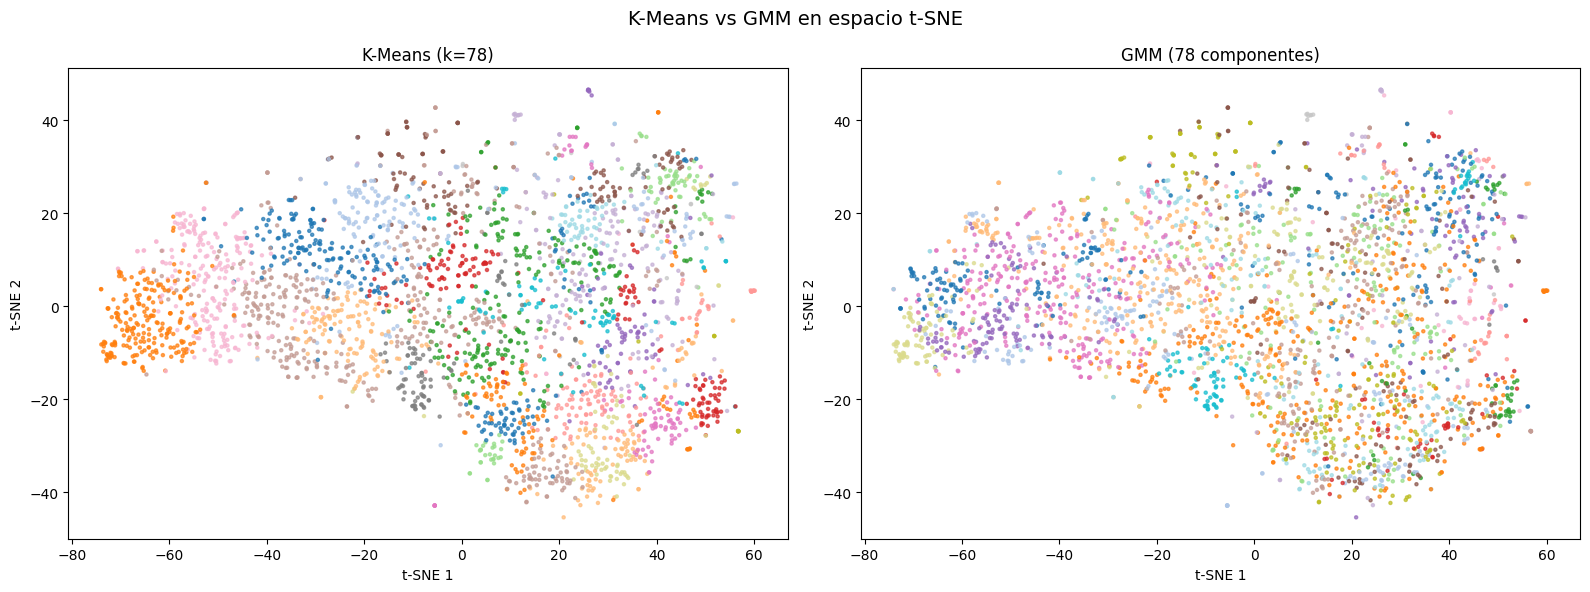

In [14]:
# Comparación en t-SNE
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

km_sample = kmeans.labels_[idx_sample]
gm_sample = gm_labels[idx_sample]

axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=km_sample, s=5, cmap='tab20', alpha=0.7)
axes[0].set_title(f"K-Means (k={K_OPTIMAL})")

axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=gm_sample, s=5, cmap='tab20', alpha=0.7)
axes[1].set_title(f"GMM ({K_OPTIMAL} componentes)")

for ax in axes:
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")

plt.suptitle("K-Means vs GMM en espacio t-SNE", fontsize=14)
plt.tight_layout()
plt.show()